<a href="https://colab.research.google.com/github/codehacker4655/ML-with-theory-inform-of-comments-/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# DECISION TREE CLASSIFICATION
# =========================

# 1️⃣ Training Process

# - Start with the dataset D = {(x1, y1), (x2, y2), ..., (xn, yn)}
#   where xi = feature vector, yi = class label
# - Choose the root node:
#   - Evaluate all features and possible thresholds
#   - Use impurity measures to choose best split:
#     - Gini Index: Gini(D) = 1 - sum(p_k^2)
#     - Entropy / Information Gain:
#       Entropy(D) = - sum(p_k * log2(p_k))
#       IG(D, feature) = Entropy(D) - sum_v(|D_v|/|D| * Entropy(D_v))
# - Split the dataset according to the chosen feature & threshold
# - Recursively repeat for child nodes:
#   - Check best splits using impurity measures
#   - Stop recursion when:
#       1. All samples in node belong to the same class
#       2. No features left
#       3. Maximum depth reached (pre-pruning)
#       4. Node has too few samples (min_samples_split)
# - Assign class label to leaf nodes (majority class)
# - Optionally, perform pruning to avoid overfitting

# -------------------------
# Pruning Techniques
# -------------------------
# 1. Pre-Pruning (Early Stopping)
#    - Stop tree growth if:
#       * Splitting does not improve information gain or reduce impurity
#       * Node depth exceeds max_depth
#       * Node has less than min_samples_split
# 2. Post-Pruning
#    - Grow full tree first
#    - Remove nodes/branches that do not improve validation accuracy
#    - Methods: Reduced Error Pruning, Cost Complexity Pruning (CCP)

# -------------------------
# Why pruning reduces overfitting
# -------------------------
# - Overfitting occurs when tree fits training data too closely, including noise
# - Pruning removes branches that capture noise, keeping the tree simpler
# - Simpler tree generalizes better on unseen data
# - Key: Training accuracy may slightly decrease, but validation/test accuracy improves
# - Too much pruning → underfitting; too little → overfitting
# - Use validation set / cross-validation to find optimal pruning level

# 2️⃣ Prediction Process

# - Input a new sample x_new = [x1, x2, ..., xm]
# - Start at root node
# - Check split condition at current node:
#     - If true → move to left child
#     - If false → move to right child
# - Repeat until reaching a leaf node
# - Predict leaf node's majority class
# - Optionally, provide class probabilities:
#     P(class k) = (# samples of class k in leaf) / (total samples in leaf)

# Example:
# Tree:
# Root: x1 <= 5?
#   Left: x2 <= 3?
#       Left: Class A
#       Right: Class B
#   Right: Class C
# New sample: x_new = [4, 4]
# Root check: 4 <= 5 → True → Go Left
# Next node: 4 <= 3 → False → Go Right
# Leaf → Predict Class B

# =========================
# Summary
# =========================
# 1. Training: recursively split data to minimize impurity, assign majority class to leaves
# 2. Prediction: traverse tree according to feature conditions until leaf → predict class
# 3. Pruning: removes low-importance branches to reduce overfitting
# 4. Overfitting reduction: pruned tree ignores noise, improves generalization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
from pickle import load
from sklearn.datasets import load_iris
iris=load_iris()

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


In [5]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [7]:
print(iris['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [8]:
#independent features
X=pd.DataFrame(iris['data'],columns=["sepal_length","sepal_width","petal_length","petal_width"])

In [9]:
#dependent features
y=iris['target']

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
# ============================
# Why we don't standardize in Decision Trees
# ============================

# 1. What is standardization?
#    - It means rescaling features (like making values between 0 and 1,
#      or mean = 0, std = 1).
#    - Needed in algorithms like KNN, SVM, Logistic Regression
#      because they use distances or weights.

# 2. How Decision Trees work:
#    - A tree splits data using simple yes/no questions:
#        Example: "Is Age <= 30?"
#    - The algorithm checks which threshold gives the purest split
#      (lowest impurity like Gini/Entropy).
#    - The actual scale of numbers does not matter, only their order.

# 3. Why scaling is unnecessary:
#    - Example:
#        Original feature: Age = [20, 30, 40]
#        Standardized Age = [0.2, 0.3, 0.4]
#        Split at "Age <= 30" becomes "Std Age <= 0.3"
#    - The split is identical → Tree structure does not change.
#    - So scaling has no effect.

# 4. Key reason:
#    - Decision Trees depend only on the order of values,
#      not on their magnitude.
#    - They are invariant to monotonic transformations (like scaling,
#      shifting, or standardizing).

# ============================
# Final Answer:
# ============================
# We do NOT standardize features for Decision Trees
# because scaling does not change splits.
# The model only cares about order, not size.

In [12]:
# ==============================================
# Why we don't standardize / normalize in Decision Trees
# ==============================================

# 🔹 1. What is standardization?
# - Standardization (or normalization) means rescaling features:
#     * Standardization: mean = 0, std = 1
#     * Normalization: values scaled to range [0, 1]
# - This is very important for algorithms like:
#     * Logistic Regression, SVM, KNN, Neural Networks
#   because they rely on:
#     * distances, dot products, or gradient descent

# 🔹 2. How Decision Trees split data
# - A decision tree does NOT use distances or weights between features
# - It only asks simple yes/no questions:
#       Example: "Is Age <= 30?"
# - The algorithm checks which split gives best reduction in impurity
#   (Gini Index / Entropy)
# - Whether "Age" is measured in:
#       years (0–100) OR standardized to (0–1)
#   → The order of values is the same
#   → Splits remain the same
#   → Tree structure is unchanged

# 🔹 3. Why standardization is unnecessary
# 1. Tree splits are order-based, not distance-based
#    - A split at "Age <= 30" is the same as "Standardized Age <= 0.3"
#    - Scaling does not change relative ordering
#
# 2. Decision Trees are invariant to monotonic transformations
#    - Multiplying, dividing, or shifting features does not affect
#      which split gives maximum information gain
#
# 3. Unlike linear or distance-based models
#    - In Logistic Regression:
#         Feature with range [0,1000] dominates over [0,1] unless standardized
#    - In Decision Trees:
#         Each feature is checked independently → no domination issue

# 🔹 4. When scaling might matter
# - Normally scaling makes NO difference for Decision Trees
# - But in some special cases:
#     * When combining trees with distance-based methods
#       (e.g., k-means clustering on tree embeddings)
#     * Or gradient boosting models combined with nearest neighbors
#   → Then scaling can play a role in the second stage, not in the tree itself

# ✅ Final Answer:
# We do NOT standardize features for Decision Trees because:
# - They only care about the ORDER of feature values, not the scale
# - Scaling does not change splits or impurity calculations
# - Tree structure remains the same

In [13]:
##apply decisio tree classifier
# ==============================================
# Decision Tree Classification – Summary (Iris Dataset)
# ==============================================

# Step 0: Dataset
# - Iris dataset: 150 samples, 4 features
#   Features: sepal length, sepal width, petal length, petal width
#   Classes: Setosa, Versicolor, Virginica

# Step 1: Start at root node
# - Consider all features
# - For each feature, try all possible thresholds
# - Calculate entropy for each split:
#       Entropy(S) = - sum(p_k * log2(p_k)) for k in classes
# - Calculate information gain:
#       IG = Entropy(parent) - sum_v(|S_v|/|S| * Entropy(S_v))
# - Choose the feature & threshold with highest IG → root split

# Step 2: Split the data
# - Divide dataset into child nodes based on chosen threshold
#   Example: Petal length ≤ 2.45 → left node, > 2.45 → right node

# Step 3: Recursive splitting
# - For each child node, repeat Step 1 & Step 2 using subset of data
# - Continue until stopping criteria:
#     * Node is pure (all samples same class)
#     * No more features or thresholds available
#     * Minimum samples per node / max depth reached

# Step 4: Assign class labels to leaf nodes
# - Each leaf gets majority class of samples in that node
#   Example:
#       Left leaf → Setosa
#       Right-left leaf → Versicolor
#       Right-right leaf → Virginica

# Step 5: Optional pruning
# - Remove splits that do not improve validation accuracy
# - Helps reduce overfitting

# Step 6: Prediction on new data
# - Start at root node
# - At each node, check the feature threshold → move left/right
# - Repeat until a leaf node is reached
# - Assign class label of leaf as prediction

# Example predictions:
# Sample: [5.0, 3.4, 1.5, 0.2]
#   Root: Petal length ≤ 2.45 → yes → left leaf → predict Setosa
# Sample: [6.0, 2.8, 4.5, 1.5]
#   Root: Petal length ≤ 2.45 → no → right
#   Next split: Petal width ≤ 1.75 → yes → leaf → predict Versicolor

# Key Points:
# 1. Each split chooses feature & threshold with highest info gain
# 2. Same feature can be reused in multiple nodes
# 3. Splitting continues recursively until stopping criteria
# 4. Leaf nodes assign majority class
# 5. Optional pruning reduces overfitting
# 6. Prediction = traverse tree using thresholds → reach leaf → output class

In [14]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(max_depth=2)

In [15]:
tree.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=2)

In [16]:
# ==============================================================================
# FINAL SUMMARY: DECISION TREE TRAINING PROCESS WITH GINI IMPURITY
# ==============================================================================

# THEORETICAL TRAINING PROCESS:
# -----------------------------
# A decision tree learns by recursively partitioning the training data into
# subsets. The core idea is to find the best possible "split" at each step to
# create the purest child nodes. The process is a greedy, top-down approach.

# 1. Gini Impurity: A metric to measure the "disorder" or "impurity" of a node.
#    - A Gini value of 0.0 means the node is perfectly pure (all samples belong
#      to a single class).
#    - Formula: Gini(S) = 1 - sum(p_k^2), where p_k is the proportion of class k.

# 2. Gini Gain: The metric used to select the best split.
#    - It measures the reduction in Gini Impurity achieved by a potential split.
#    - The algorithm tests every possible split (on all features and all
#      thresholds) and calculates the Gini Gain for each.
#    - The best split is the one that provides the HIGHEST Gini Gain.
#    - Formula: Gini Gain = Gini(Parent) - Gini_weighted_avg(Children)

# 3. Recursive Splitting:
#    - The chosen split is applied, and the data is partitioned into child nodes.
#    - This process is repeated for each resulting child node that is not pure.
#    - The recursion stops when a node is pure, the number of samples is too low,
#      or the maximum tree depth is reached.


# ==============================================================================
# DETAILED EXAMPLE OF THE FIRST TWO SPLITS (FROM THE IMAGE)
# ==============================================================================

# ------------------------------------------------------------------------------
# FIRST SPLIT: THE ROOT NODE
# ------------------------------------------------------------------------------
# Parent Node:
# - Samples: 120
# - Value: [40 Setosa, 37 Versicolor, 43 Virginica]
#
# Calculation of Parent Gini:
# gini_parent = 1 - ( (40/120)^2 + (37/120)^2 + (43/120)^2 )
# gini_parent = 1 - (0.333^2 + 0.308^2 + 0.358^2) = 0.666
#
# Best Split Found: X[2] <= 2.45 (Petal Length)
#
# Child Nodes after Split:
# - Left Child (X[2] <= 2.45):
#   - Samples: 40
#   - Value: [40, 0, 0]
#   - Gini_left = 1 - ( (40/40)^2 + (0/40)^2 + (0/40)^2 ) = 0.0 (Pure)
# - Right Child (X[2] > 2.45):
#   - Samples: 80
#   - Value: [0, 37, 43]
#   - Gini_right = 1 - ( (0/80)^2 + (37/80)^2 + (43/80)^2 ) = 0.497
#
# Calculation of Gini Gain for this Split:
# - Weighted Average Gini of Children:
#   gini_weighted_avg = (40/120) * Gini_left + (80/120) * Gini_right
#   gini_weighted_avg = (40/120) * 0.0 + (80/120) * 0.497 = 0.331
# - Gini Gain:
#   gini_gain = gini_parent - gini_weighted_avg = 0.666 - 0.331 = 0.335
#
# This Gini Gain of 0.335 was the highest found among all possible splits.

# ------------------------------------------------------------------------------
# SECOND SPLIT: THE RIGHT CHILD NODE
# ------------------------------------------------------------------------------
# Parent Node for this split:
# - Samples: 80
# - Value: [0, 37, 43]
# - Parent Gini: 0.497
#
# Best Split Found: X[2] <= 4.75 (Petal Length)
#
# Child Nodes after Split:
# - Left Child (X[2] <= 4.75):
#   - Samples: 38
#   - Value: [0, 37, 1]
#   - Gini_left = 1 - ( (0/38)^2 + (37/38)^2 + (1/38)^2 ) = 0.052
# - Right Child (X[2] > 4.75):
#   - Samples: 42
#   - Value: [0, 0, 42]
#   - Gini_right = 1 - ( (0/42)^2 + (0/42)^2 + (42/42)^2 ) = 0.0 (Pure)
#
# Calculation of Gini Gain for this Split:
# - Weighted Average Gini of Children:
#   gini_weighted_avg = (38/80) * Gini_left + (42/80) * Gini_right
#   gini_weighted_avg = (38/80) * 0.052 + (42/80) * 0.0 = 0.025
# - Gini Gain:
#   gini_gain = gini_parent - gini_weighted_avg = 0.497 - 0.025 = 0.472
#
# This Gini Gain of 0.472 was the highest for this particular subset of samples.
# The algorithm continues to split the remaining impure nodes until all are pure.

In [17]:
# ==============================================================================
# CORRECTED SUMMARY OF THE DECISION TREE TRAINING PROCESS
# ==============================================================================

# The key is that the algorithm doesn't just "take a feature" first.
# Instead, it works like this:

# 1. At a given node, the algorithm systematically evaluates all possible splits
#    across all features and all possible thresholds.

# 2. For each potential split, it calculates the Gini Gain. The Gini Gain tells
#    the algorithm how much the Gini Impurity would be reduced if that split were made.

# 3. The algorithm chooses the split with the highest Gini Gain
#    (the one that reduces impurity the most).

# 4. This process is repeated for the resulting child nodes.

# 5. The final part, "until we get pure nodes," is absolutely correct.
#    That's one of the main stopping conditions for the algorithm.

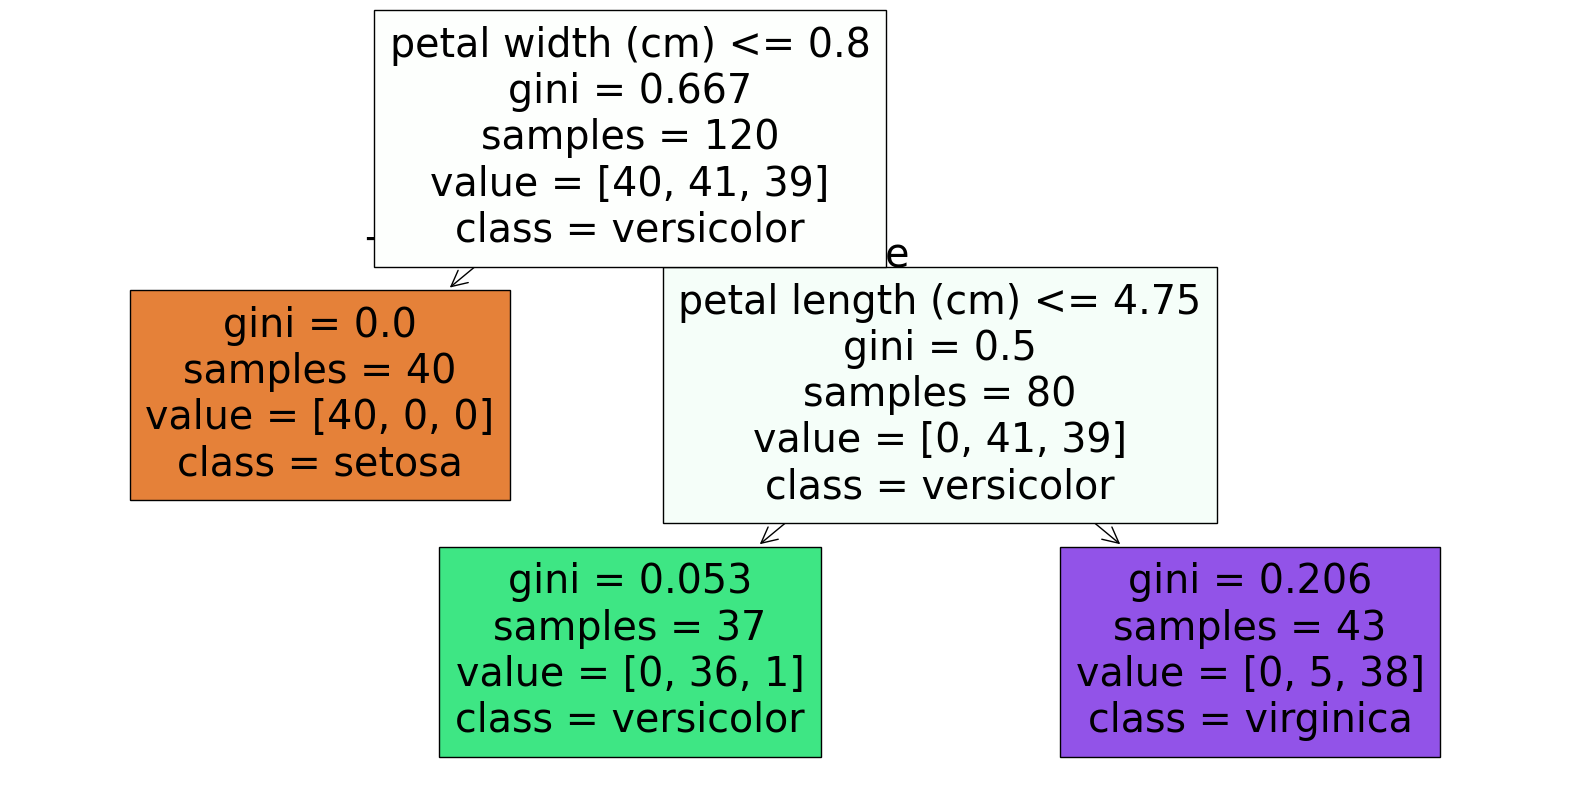

In [18]:
plt.figure(figsize=(20,10))
plot_tree(decision_tree=tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True)
plt.show()

In [19]:
y_pred=tree.predict(x_test)

In [20]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



# preprunning

In [21]:
# 🌳 Decision Tree Classifier / Regressor Hyperparameters

# 1. max_depth
# - Maximum depth of the tree.
# - Prevents tree from growing too deep (overfitting).

# 2. min_samples_split
# - Minimum number of samples required to split a node.
# - Higher values → less splits → simpler tree.

# 3. min_samples_leaf
# - Minimum number of samples required to be at a leaf node.
# - Prevents leaves with very few samples (overfitting).

# 4. max_features
# - Number of features to consider when looking for the best split.
# - 'sqrt', 'log2', or an integer value.
# - Helps control randomness and reduce overfitting.

# 5. max_leaf_nodes
# - Maximum number of leaf nodes in the tree.
# - Limits tree complexity.

# 6. criterion
# - Function to measure the quality of a split.
# - For classification: "gini" or "entropy".
# - For regression: "squared_error", "absolute_error", etc.

# 7. splitter
# - Strategy used to choose the split at each node.
# - "best" → best split
# - "random" → random split

# 8. min_weight_fraction_leaf
# - Minimum weighted fraction of the total samples at a leaf node.
# - Useful for weighted datasets.

# 9. ccp_alpha (Cost Complexity Pruning)
# - Complexity parameter for Minimal Cost-Complexity Pruning.
# - Larger alpha → more pruning (simpler tree).

# ✅ These are hyperparameters (you choose them).
# ✅ The tree itself learns the split rules (like thresholds on features).

In [22]:
param={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,8,9,10],
    'min_samples_split':[2,3,4,5,6,7,8,9,10],
    'min_samples_leaf':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [23]:
param

{'criterion': ['gini', 'entropy', 'log_loss'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
 'min_samples_leaf': [1, 2, 3, 4, 5],
 'max_features': ['auto', 'sqrt', 'log2']}

In [24]:
from sklearn.model_selection import GridSearchCV
treemodel=DecisionTreeClassifier()
grid=GridSearchCV(treemodel,param,cv=5,scoring='accuracy')

In [25]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [26]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'min_samples_leaf': 1,
 'min_samples_split': 7,
 'splitter': 'random'}

In [27]:
grid.best_score_

np.float64(0.975)

In [28]:
y_pred=grid.predict(x_test)

In [29]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [30]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

